In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
df = pd.read_csv("tmdb-movies.csv")
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [29]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

(10866, 21)

In [8]:
# Wo fehlen Werte?
df.isna().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

In [30]:
# wie viele Werte sind unique?
df.nunique()


id                      10865
imdb_id                 10855
popularity              10814
budget                    557
revenue                  4702
original_title          10571
cast                    10719
homepage                 2896
director                 5067
tagline                  7997
keywords                 8804
overview                10847
runtime                   247
genres                   2039
production_companies     7445
release_date             5909
vote_count               1289
vote_average               72
release_year               56
budget_adj               2614
revenue_adj              4840
dtype: int64

In [14]:
# Lets take a look at vote_average
df.vote_average

0        6.5
1        7.1
2        6.3
3        7.5
4        7.3
        ... 
10861    7.4
10862    5.7
10863    6.5
10864    5.4
10865    1.5
Name: vote_average, Length: 10866, dtype: float64

In [31]:
# Wie veiel doppelte Werte gibt es?
df.duplicated().sum()

np.int64(1)

In [32]:
# Erstelle col profit aus Umsatz minus budget.
#Berechne Statstische Werte aus profit
df["profit"]  = df["revenue"] - df["budget"]
print(df["profit"].describe())

count    1.086600e+04
mean     2.519762e+07
std      9.658799e+07
min     -4.139124e+08
25%      0.000000e+00
50%      0.000000e+00
75%      9.083358e+06
max      2.544506e+09
Name: profit, dtype: float64


In [33]:
# Entferne Dublikate
df.drop_duplicates(inplace=True)
df.duplicated().any(axis=0)

np.False_

In [34]:
df.columns

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview',
       'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj', 'profit'],
      dtype='object')

In [35]:
# Entferne col die ich nicht benutzen werde
df.drop(["id", "imdb_id", "original_title", "cast", "homepage", "director", "tagline", "keywords", "overview", "runtime", "production_companies", "release_date", "budget_adj", "revenue_adj"], axis=1, inplace=True)
df.columns

Index(['popularity', 'budget', 'revenue', 'genres', 'vote_count',
       'vote_average', 'release_year', 'profit'],
      dtype='object')

In [39]:
df.head()
df.shape

(10865, 8)

In [41]:
df.isnull().sum()

popularity       0
budget           0
revenue          0
genres          23
vote_count       0
vote_average     0
release_year     0
profit           0
dtype: int64

In [42]:
# Alle N/A Werte sollen entfernt werden
df.dropna(inplace=True)
df.isnull().sum()

popularity      0
budget          0
revenue         0
genres          0
vote_count      0
vote_average    0
release_year    0
profit          0
dtype: int64

In [44]:
# In genres haben die Werte | das muss entfernt werden
df["genres"] = df["genres"].apply(lambda x: x.split("|") [0])
df["genres"]

0             Action
1             Action
2          Adventure
3             Action
4             Action
            ...     
10861    Documentary
10862         Action
10863        Mystery
10864         Action
10865         Horror
Name: genres, Length: 10842, dtype: object

In [48]:
def catigorize_col (df, col, labels):
    edges = [df[col].describe()["min"],
             df[col].describe()["25%"],
             df[col].describe()["50"],
             df[col].describe()["75%"],
             df[col].describe()["max"]]
    df[col] = pd.cut(df[col],edges, labels= labels, duplicates='drop')
    return df

In [49]:
#Genau der gleiche code wie oben
#pd.qcut setzt die quartilen automatisch ein
def categorize_col(df, col, labels):
    """Kategorisiert eine Spalte basierend auf ihren Quartilen."""
    df[col] = pd.qcut(df[col], q=4, labels=labels, duplicates="drop")
    return df


In [50]:
# convert vote_average
labels = ["not_popular", "below_Average", "Average", "popular"]
categorize_col (df, "vote_average", labels)

df["vote_average"].unique()


['Average', 'popular', 'below_Average', 'not_popular']
Categories (4, object): ['not_popular' < 'below_Average' < 'Average' < 'popular']

In [51]:
df.dropna(inplace=True)
df.isnull().sum()


popularity      0
budget          0
revenue         0
genres          0
vote_count      0
vote_average    0
release_year    0
profit          0
dtype: int64

In [52]:
labels = ["low", "average", "high"]
categorize_col (df, "profit", labels)

df["profit"].unique()

['high', 'average', 'low']
Categories (3, object): ['low' < 'average' < 'high']

In [53]:
df.dropna(inplace=True)
df.isna().sum()

popularity      0
budget          0
revenue         0
genres          0
vote_count      0
vote_average    0
release_year    0
profit          0
dtype: int64

In [58]:
df.nunique()

popularity      10791
budget            557
revenue          4702
genres             20
vote_count       1289
vote_average        4
release_year       56
profit              3
dtype: int64

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10842 entries, 0 to 10865
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   popularity    10842 non-null  float64 
 1   budget        10842 non-null  int64   
 2   revenue       10842 non-null  int64   
 3   genres        10842 non-null  object  
 4   vote_count    10842 non-null  int64   
 5   vote_average  10842 non-null  category
 6   release_year  10842 non-null  int64   
 7   profit        10842 non-null  category
dtypes: category(2), float64(1), int64(4), object(1)
memory usage: 614.4+ KB


In [59]:
#EDA
# Bekommen Filme die Populärer sind mehr Umsatz?

In [60]:
df["popularity"].mean()

np.float64(0.6474605913115661)

In [61]:
less_popular = df.query("popularity <= 0.6474605913115661")
more_popular = df.query("popularity > 0.6474605913115661")

In [62]:
print(less_popular.revenue.mean(), more_popular.revenue.mean())

7695388.447855124 121990488.03010471


In [63]:
# Antwort: Ja Filme die mehr Populärer sind haben höheren Umsatz

NameError: name 'font_size' is not defined

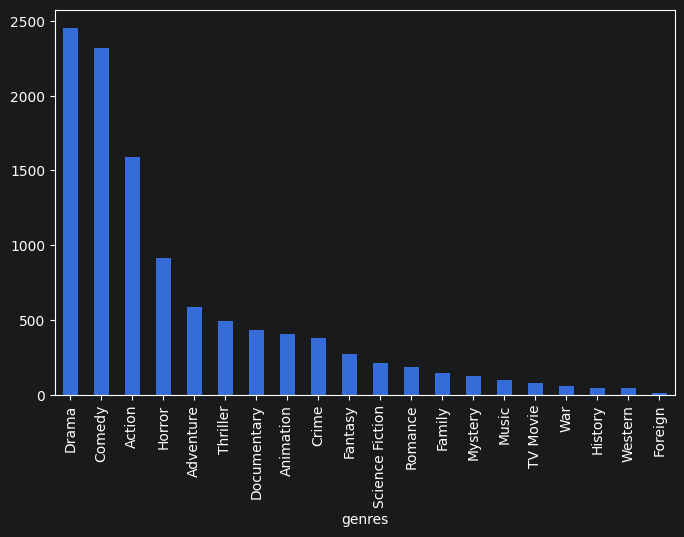

In [72]:
# Visualisierung
plt.figure(figsize(8,5))
df["genres"].value_counts().plot(kind="bar")
plt.title("The most filmed genres", font_size=font_size(10))
xlabels("genres", font_size=font_size(10))
ylabels("Count", font_size=font_size(10))
plt.show()

In [73]:
df["genres"].describe()

count     10842
unique       20
top       Drama
freq       2453
Name: genres, dtype: object